# Modality Detection for Multimodal Disease Prediction

In [1]:
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Exploration & Visualization

In [3]:
import os

dataset_path = "/content/drive/MyDrive/modality_dataset"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("MODALITY DATASET SUMMARY\n")

classes = sorted(os.listdir(train_path))

print(f"\nNumber of Classes: {len(classes)}")
print(f"Classes: {classes}")

train_total = 0
test_total = 0

print("TRAIN DATASET\n")


for cls in classes:

    cls_path = os.path.join(
        train_path,
        cls
    )

    count = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(
            os.path.join(cls_path, f)
        )
    ])

    train_total += count

    print(
        f"{cls:<15} : {count}"
    )

print(f"\nTotal Train Images: {train_total}")


print("\nTEST DATASET\n")


for cls in classes:

    cls_path = os.path.join(
        test_path,
        cls
    )

    count = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(
            os.path.join(cls_path, f)
        )
    ])

    test_total += count

    print(
        f"{cls:<15} : {count}"
    )

print(f"\nTotal Test Images: {test_total}")

print("\nOVERALL DATASET\n")

print(
    f"Grand Total Images: {train_total + test_total}"
)

MODALITY DATASET SUMMARY


Number of Classes: 4
Classes: ['brain_ct', 'brain_mri', 'chest_ct', 'chest_xray']
TRAIN DATASET

brain_ct        : 400
brain_mri       : 400
chest_ct        : 400
chest_xray      : 400

Total Train Images: 1600

TEST DATASET

brain_ct        : 100
brain_mri       : 100
chest_ct        : 100
chest_xray      : 100

Total Test Images: 400

OVERALL DATASET

Grand Total Images: 2000


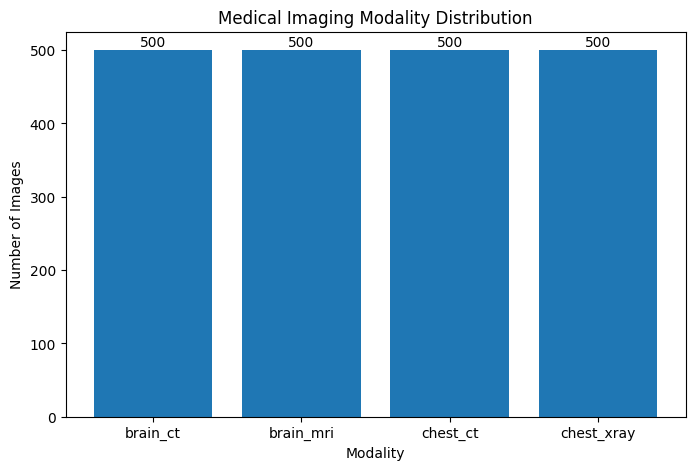

In [4]:
import os
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/modality_dataset"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

classes = sorted(os.listdir(train_path))

total_counts = []

for cls in classes:

    train_count = len(
        os.listdir(
            os.path.join(
                train_path,
                cls
            )
        )
    )

    test_count = len(
        os.listdir(
            os.path.join(
                test_path,
                cls
            )
        )
    )

    total_counts.append(
        train_count + test_count
    )

plt.figure(figsize=(8,5))

bars = plt.bar(
    classes,
    total_counts
)

plt.title(
    "Medical Imaging Modality Distribution"
)

plt.xlabel(
    "Modality"
)

plt.ylabel(
    "Number of Images"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        str(int(height)),
        ha='center'
    )

plt.show()

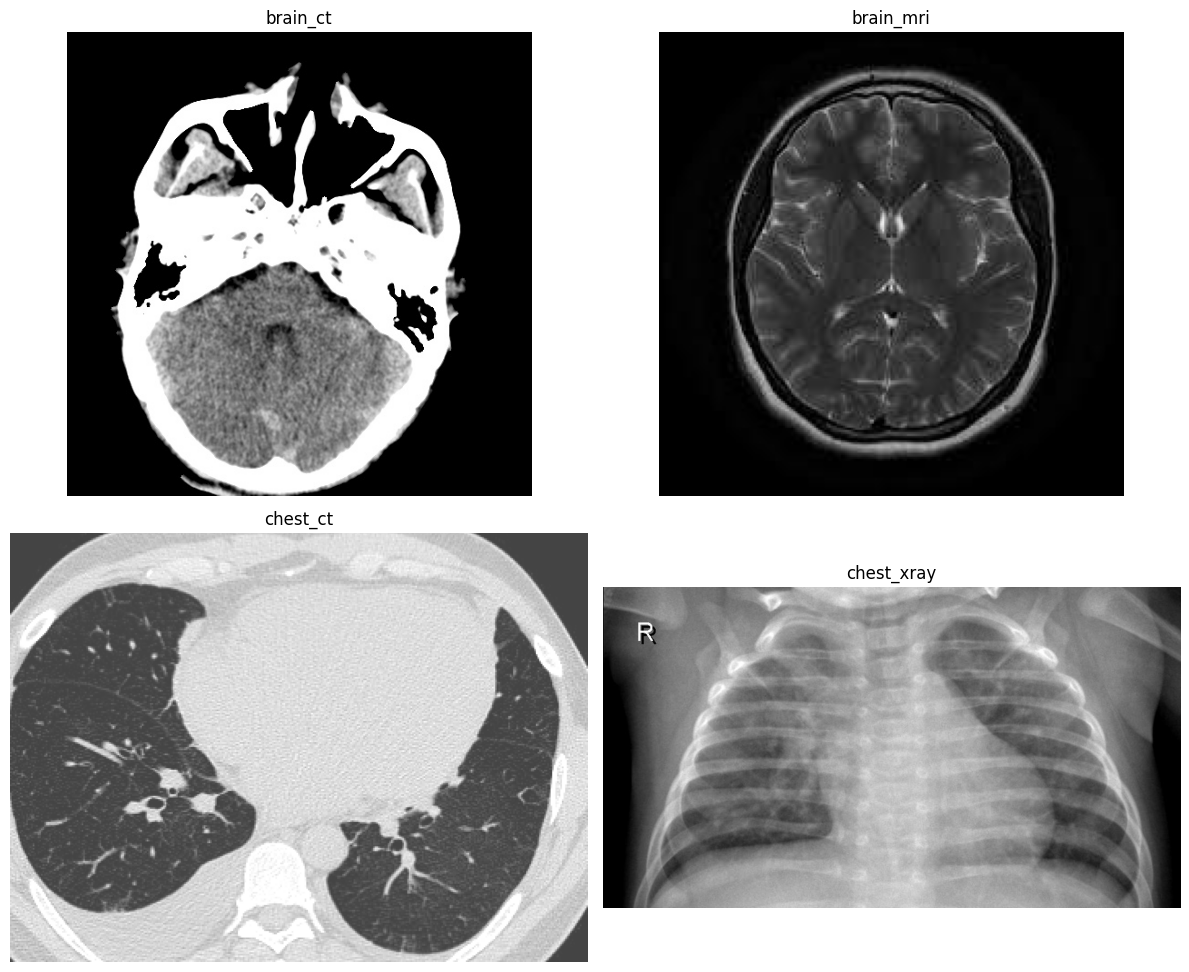

In [5]:
import random

from PIL import Image

dataset_path = "/content/drive/MyDrive/modality_dataset/train"

classes = sorted(
    os.listdir(dataset_path)
)

plt.figure(figsize=(12,10))

for i, cls in enumerate(classes):

    class_path = os.path.join(
        dataset_path,
        cls
    )

    image_name = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_name
    )

    image = Image.open(image_path)

    plt.subplot(
        2,
        2,
        i+1
    )

    plt.imshow(image, cmap="gray")

    plt.title(
        cls
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
dataset_path = "/content/drive/MyDrive/modality_dataset/train"

for cls in sorted(os.listdir(dataset_path)):

    class_path = os.path.join(
        dataset_path,
        cls
    )

    image_name = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_name
    )

    image = Image.open(image_path)

    print(f"\n{cls}")

    print(
        "Size:",
        image.size
    )

    print(
        "Mode:",
        image.mode
    )


brain_ct
Size: (512, 512)
Mode: L

brain_mri
Size: (236, 294)
Mode: RGB

chest_ct
Size: (267, 194)
Mode: RGB

chest_xray
Size: (1470, 1033)
Mode: L


# Model Loading, Training & Testing

In [7]:
from torchvision import datasets
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    transforms.Resize(
        (224,224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    transforms.Resize(
        (224,224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/modality_dataset/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/modality_dataset/test",
    transform=test_transform
)

print(
    train_dataset.classes
)

print(
    train_dataset.class_to_idx
)

print(
    "Train Images:",
    len(train_dataset)
)

print(
    "Test Images:",
    len(test_dataset)
)

['brain_ct', 'brain_mri', 'chest_ct', 'chest_xray']
{'brain_ct': 0, 'brain_mri': 1, 'chest_ct': 2, 'chest_xray': 3}
Train Images: 1600
Test Images: 400


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(
    "Train Batches:",
    len(train_loader)
)

print(
    "Test Batches:",
    len(test_loader)
)

Train Batches: 50
Test Batches: 13


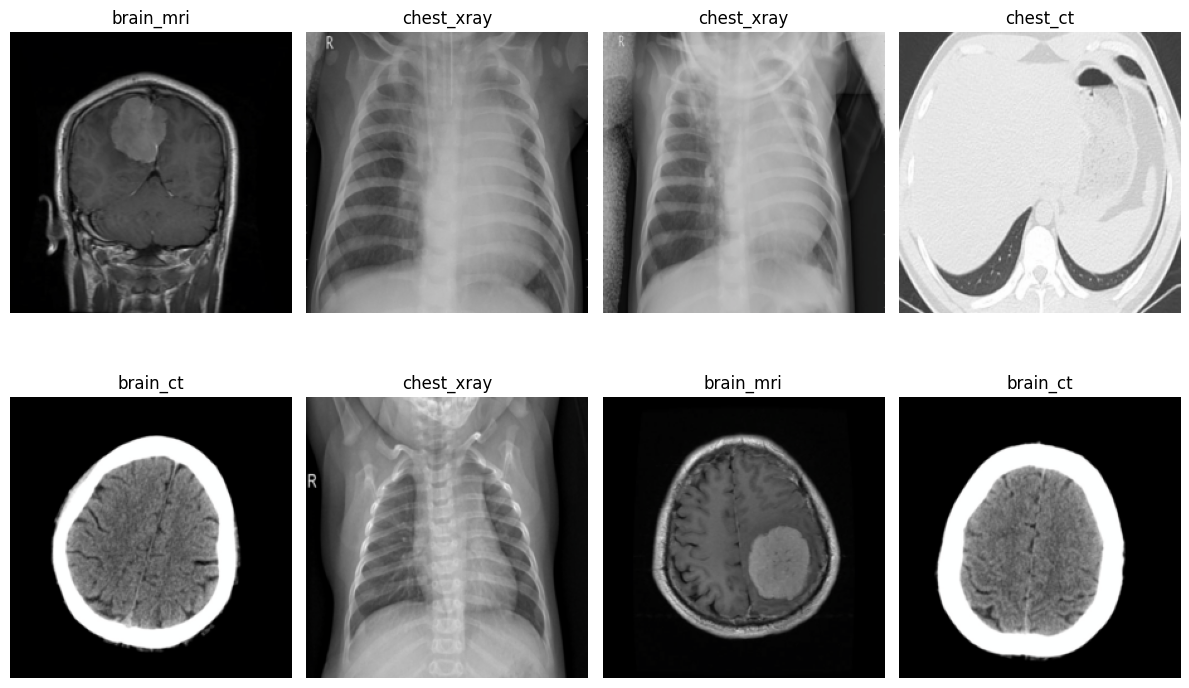

In [9]:
import matplotlib.pyplot as plt

images, labels = next(
    iter(train_loader)
)

class_names = train_dataset.classes

plt.figure(figsize=(12,8))

for i in range(8):

    img = images[i]

    img = img.permute(
        1,2,0
    ).numpy()

    img = img * [0.229,0.224,0.225] + \
          [0.485,0.456,0.406]

    img = img.clip(
        0,
        1
    )

    plt.subplot(
        2,
        4,
        i+1
    )

    plt.imshow(img)

    plt.title(
        class_names[
            labels[i]
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [11]:
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

model = efficientnet_b0(
    weights=
    EfficientNet_B0_Weights.DEFAULT
)

model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.2,
        inplace=True
    ),

    nn.Linear(
        1280,
        4
    )

)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 67.1MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [13]:
images, labels = next(
    iter(train_loader)
)

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


In [14]:
num_epochs = 5

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.3707
Epoch [2/5] Loss: 0.0354
Epoch [3/5] Loss: 0.0105
Epoch [4/5] Loss: 0.0067
Epoch [5/5] Loss: 0.0085


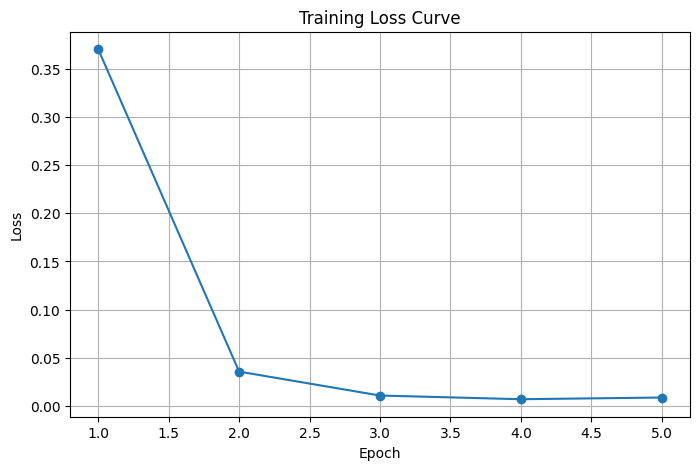

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker="o"
)

plt.title(
    "Training Loss Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.show()

In [16]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = (
    100 * correct / total
)

print(
    f"Test Accuracy: "
    f"{accuracy:.2f}%"
)

Test Accuracy: 100.00%


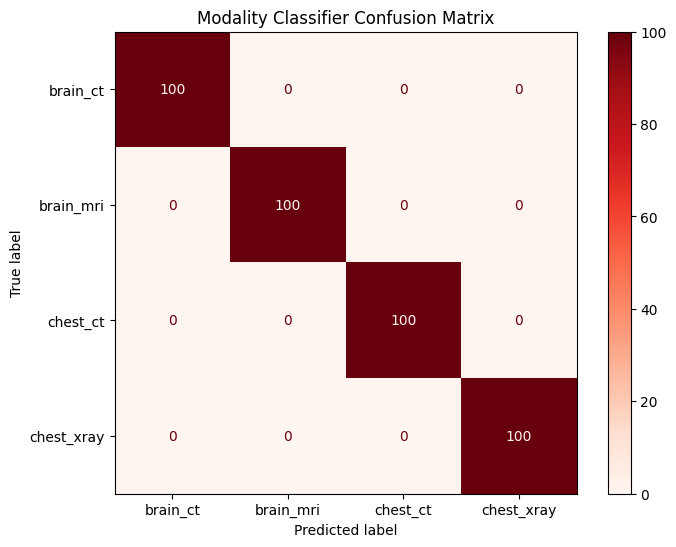

In [17]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(
    figsize=(8,6)
)

disp.plot(
    cmap="Reds",
    ax=ax
)

plt.title(
    "Modality Classifier Confusion Matrix"
)

plt.show()

In [18]:
from sklearn.metrics import (
    classification_report
)

print(

    classification_report(
        all_labels,
        all_preds,
        target_names=
        train_dataset.classes
    )

)

              precision    recall  f1-score   support

    brain_ct       1.00      1.00      1.00       100
   brain_mri       1.00      1.00      1.00       100
    chest_ct       1.00      1.00      1.00       100
  chest_xray       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [19]:
torch.save(
    model.state_dict(),
    "modality_classifier.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [20]:
from google.colab import files

files.download(
    "modality_classifier.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from google.colab import files

class_names = [
    "brain_ct",
    "brain_mri",
    "chest_ct",
    "chest_xray"
]


transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    transforms.Resize(
        (224,224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])


def load_modality_model():

    model = efficientnet_b0(
        weights=None
    )

    model.classifier = nn.Sequential(

        nn.Dropout(
            p=0.2,
            inplace=True
        ),

        nn.Linear(
            1280,
            4
        )

    )

    model.load_state_dict(
        torch.load(
            "modality_classifier.pth",
            map_location=device
        )
    )

    model.to(device)

    model.eval()

    return model


def upload_and_predict_modality():

    uploaded = files.upload()

    image_path = next(
        iter(uploaded)
    )

    image = Image.open(
        image_path
    )

    plt.figure(figsize=(5,5))

    plt.imshow(image)

    plt.title(
        f"Uploaded Image: {image_path}"
    )

    plt.axis("off")

    plt.show()

    input_tensor = transform(
        image
    )

    input_tensor = input_tensor.unsqueeze(
        0
    ).to(device)

    model = load_modality_model()

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        pred_class = (
            probabilities.argmax(
                dim=1
            ).item()
        )

        confidence = (
            probabilities[
                0,
                pred_class
            ].item()
            * 100
        )

    print(
        "\nPredicted Modality:",
        class_names[pred_class]
    )

    print(
        "Confidence:",
        f"{confidence:.2f}%"
    )

    print(
        "\nClass Probabilities:\n"
    )

    for i, cls in enumerate(
        class_names
    ):

        print(
            f"{cls:<12}: "
            f"{probabilities[0][i].item()*100:.2f}%"
        )

Saving xray1.jpg to xray1.jpg


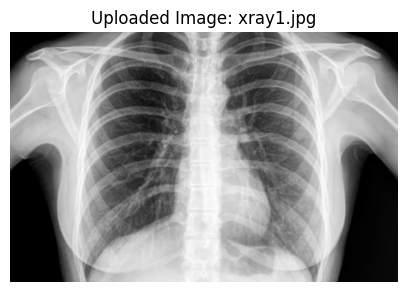


Predicted Modality: chest_xray
Confidence: 99.29%

Class Probabilities:

brain_ct    : 0.27%
brain_mri   : 0.28%
chest_ct    : 0.16%
chest_xray  : 99.29%


In [27]:
upload_and_predict_modality()

Saving xray2.jpeg to xray2.jpeg


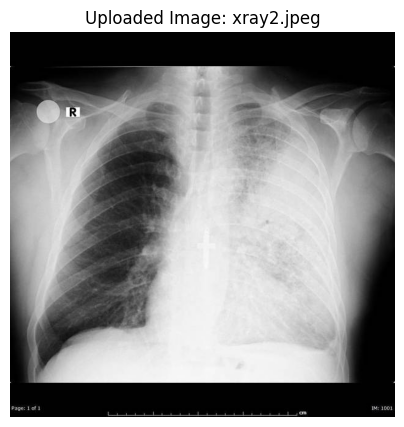


Predicted Modality: chest_xray
Confidence: 94.83%

Class Probabilities:

brain_ct    : 2.39%
brain_mri   : 1.73%
chest_ct    : 1.05%
chest_xray  : 94.83%


In [28]:
upload_and_predict_modality()

Saving chestct1.jpeg to chestct1.jpeg


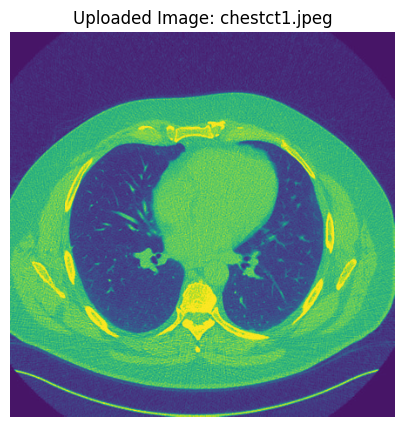


Predicted Modality: chest_ct
Confidence: 63.44%

Class Probabilities:

brain_ct    : 7.57%
brain_mri   : 28.51%
chest_ct    : 63.44%
chest_xray  : 0.49%


In [30]:
upload_and_predict_modality()

Saving chestct2.webp to chestct2.webp


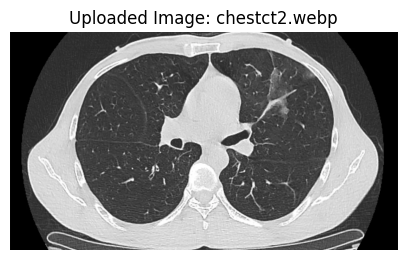


Predicted Modality: chest_ct
Confidence: 97.43%

Class Probabilities:

brain_ct    : 0.37%
brain_mri   : 2.06%
chest_ct    : 97.43%
chest_xray  : 0.14%


In [31]:
upload_and_predict_modality()

Saving mri1.png to mri1.png


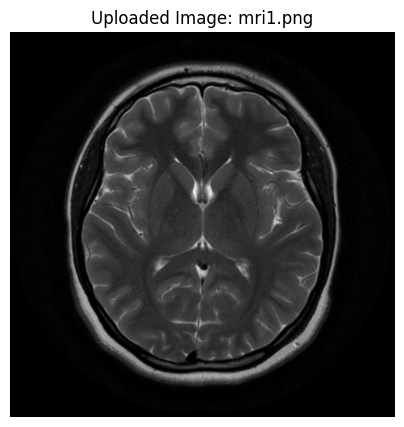


Predicted Modality: brain_mri
Confidence: 99.97%

Class Probabilities:

brain_ct    : 0.01%
brain_mri   : 99.97%
chest_ct    : 0.01%
chest_xray  : 0.00%


In [32]:
upload_and_predict_modality()

Saving mr12.jpg to mr12.jpg


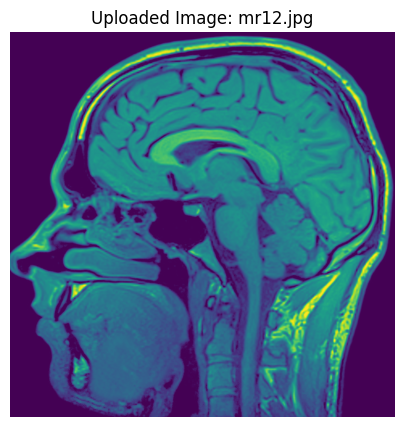


Predicted Modality: brain_mri
Confidence: 99.81%

Class Probabilities:

brain_ct    : 0.08%
brain_mri   : 99.81%
chest_ct    : 0.07%
chest_xray  : 0.04%


In [33]:
upload_and_predict_modality()

Saving brainct1.jpg to brainct1.jpg


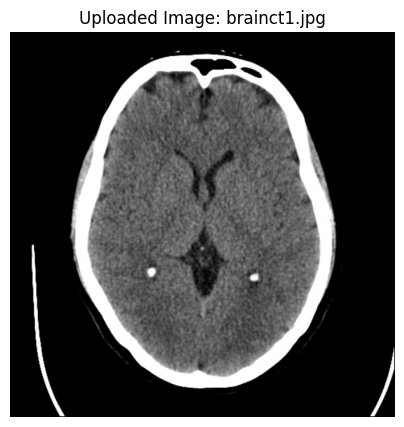


Predicted Modality: brain_ct
Confidence: 99.68%

Class Probabilities:

brain_ct    : 99.68%
brain_mri   : 0.15%
chest_ct    : 0.07%
chest_xray  : 0.10%


In [34]:
upload_and_predict_modality()

Saving nh6.png to nh6.png


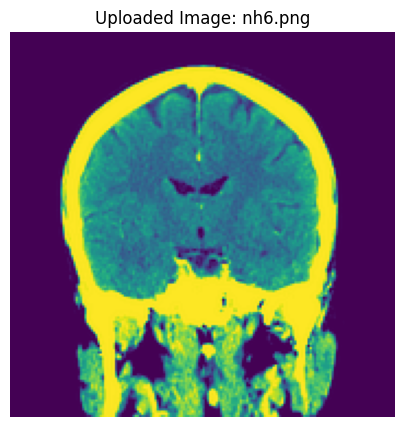


Predicted Modality: brain_ct
Confidence: 94.65%

Class Probabilities:

brain_ct    : 94.65%
brain_mri   : 4.06%
chest_ct    : 0.74%
chest_xray  : 0.55%


In [56]:
upload_and_predict_modality()